In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

#### 6.7 COMPUTER EXPERIMENT ON ADAPTIVE PREDICTION

For our first experiment with the $\mathbf{LMS}$ $\mathbf{algorithm}$, we study a first-order, $\mathbf{autoregressive}$ ($\mathbf{AR}$) process using $\mathbf{real-valued}$ $\mathbf{data}$. The process is described by the following $\mathbf{difference}$ $\mathbf{equation}$:
$$u(n) = -au(n-1) + v(n), \quad \text{(6.106)}$$
where $a$ is the (one and only) parameter of the process and $v(n)$ is a $\mathbf{zero-mean}$ $\mathbf{white-noise}$ process of variance $\sigma_v^2$. To estimate the parameter $a$, we use an $\mathbf{adaptive}$ $\mathbf{predictor}$ of $\mathbf{order}$ $\mathbf{one}$, as depicted in Fig. 6.14. The $\mathbf{real}$ $\mathbf{LMS}$ $\mathbf{algorithm}$ for adaptation of the (one and only) tap weight of the predictor is written as
$$\hat{w}(n+1) = \hat{w}(n) + \mu u(n-1)f(n), \quad \text{(6.107)}$$
where
$$f(n) = u(n) - \hat{w}(n)u(n-1)$$
is the $\mathbf{prediction}$ $\mathbf{error}$.

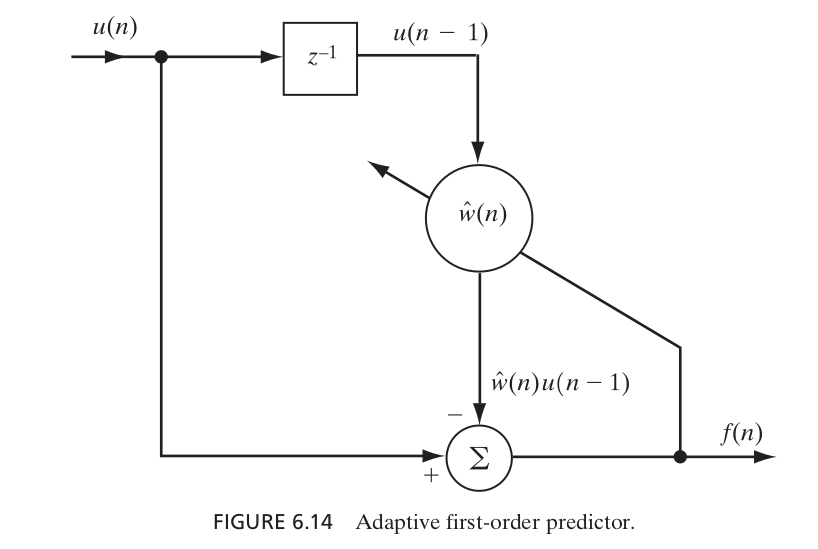

The experiment is performed for the following parameterization of the AR process, assumed to have zero mean: \
    AR parameter, $a = -0.99$ \
    Variance of the process, $\sigma_u^2=0.936$

#### Objective I. Learning Curves for Varying $\mu$

Figure 6.15 shows experimental plots of the $\mathbf{learning}$ $\mathbf{curves}$ of the $\mathbf{LMS}$ $\mathbf{algorithm}$ [i.e., the $\mathbf{mean-square}$ $\mathbf{error}$ $J(n)$ versus the $\mathbf{number}$ $\mathbf{of}$ $\mathbf{adaptation}$ $\mathbf{cycles}$, $n$] for the $\mathbf{AR}$ $\mathbf{parameter}$ $a$ previously and $\mathbf{varying}$ $\mathbf{step-size}$ $\mathbf{parameter}$ $\mu$. Specifically, the values used for $\mu$ are $0.01$, $0.05$, and $0.1$. The $\mathbf{ensemble}$ $\mathbf{averaging}$ was performed over $\mathbf{100}$ $\mathbf{independent}$ $\mathbf{Monte}$ $\mathbf{Carlo}$ $\mathbf{runs}$ of the experiment. The plots of Fig. 6.15 confirm the following properties:
* As the step-size parameter $\mu$ is reduced, the rate of convergence of the LMS algo-
rithm is correspondingly increased
* A reduction in the  step-size  parameter $\mu$ also has the effect of  reducing  variation in the experimentally computed learning curve.

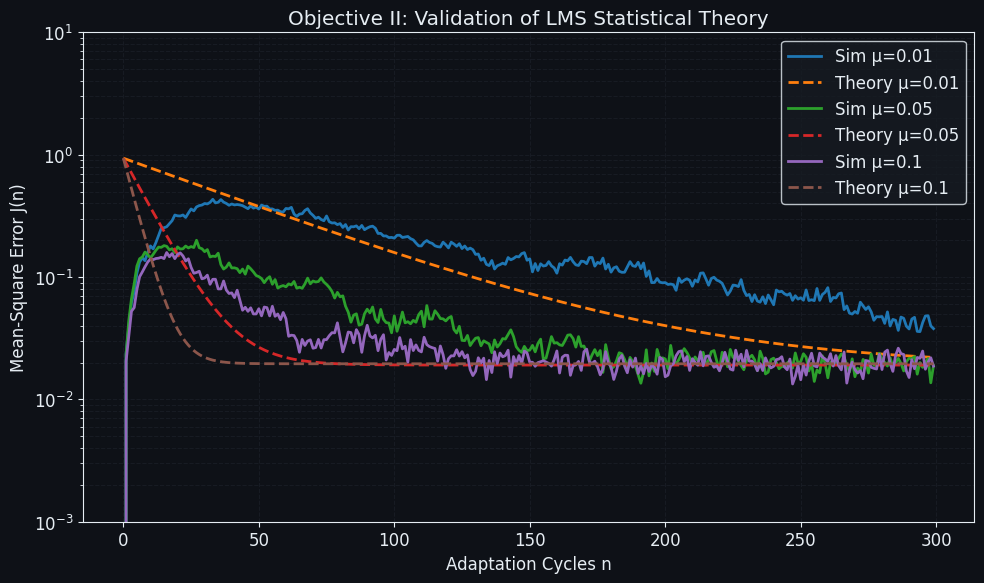


=== Steady-State Comparison ===

μ = 0.01
Sim steady-state MSE  : 0.054398
Theory steady-state MSE: 0.018714

μ = 0.05
Sim steady-state MSE  : 0.019588
Theory steady-state MSE: 0.019073

μ = 0.1
Sim steady-state MSE  : 0.019960
Theory steady-state MSE: 0.019541


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Parameters (Haykin Sec 6.7)
# ==========================================================
N_samples = 300
N_ensemble = 100
mus = [0.01, 0.05, 0.1]

a = -0.99
sigma_u2 = 0.936
sigma_v2 = sigma_u2 * (1 - a**2)
sigma_v = np.sqrt(sigma_v2)

lambda_val = sigma_u2          # Eigenvalue for order-1 case
J_min = sigma_v2               # Minimum MSE

np.random.seed(0)

# ==========================================================
# Monte Carlo Simulation
# ==========================================================
learning_curves = {}
weight_error_power = {}

for mu in mus:
  mse_runs = np.zeros((N_ensemble, N_samples))
  v_power_runs = np.zeros((N_ensemble, N_samples))

  for run in range(N_ensemble):
    u = np.zeros(N_samples + 1)
    w = 0.0
    w_opt = -a                # Wiener solution

    for n in range(1, N_samples):
      v = np.random.randn() * sigma_v
      u[n] = -a * u[n - 1] + v

      e = u[n] - w * u[n - 1]
      w = w + mu * u[n - 1] * e

      mse_runs[run, n] = e**2
      v_power_runs[run, n] = (w_opt - w)**2

  learning_curves[mu] = np.mean(mse_runs, axis=0)
  weight_error_power[mu] = np.mean(v_power_runs, axis=0)

# ==========================================================
# Theoretical Curves (Eq. 6.82)
# ==========================================================
theory_curves = {}

for mu in mus:
  steady_state_term = (mu * J_min) / (2 - mu * lambda_val)
  v0 = (-a)**2                # initial weight error squared

  theory = np.zeros(N_samples)

  for n in range(N_samples):
    theory[n] = steady_state_term + \
      (1 - mu * lambda_val)**(2 * n) * (v0 - steady_state_term)

  # Convert weight-error power to MSE:
  theory_curves[mu] = J_min + lambda_val * theory

# ==========================================================
# Plot Learning Curves (Simulation vs Theory)
# ==========================================================
plt.figure(figsize=(10, 6))

for mu in mus:
  plt.semilogy(learning_curves[mu], label=f'Sim μ={mu}', linewidth=2)
  plt.semilogy(theory_curves[mu], '--', label=f'Theory μ={mu}', linewidth=2)

plt.xlabel("Adaptation Cycles n")
plt.ylabel("Mean-Square Error J(n)")
plt.title("Objective II: Validation of LMS Statistical Theory")
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend()
plt.ylim(1e-3, 10)
plt.tight_layout()
plt.show()

# ==========================================================
# Steady-State Validation
# ==========================================================
print("\n=== Steady-State Comparison ===")

for mu in mus:
  sim_ss = np.mean(learning_curves[mu][-50:])
  theory_ss = J_min + (mu * J_min * lambda_val) / (2 - mu * lambda_val)

  print(f"\nμ = {mu}")
  print(f"Sim steady-state MSE  : {sim_ss:.6f}")
  print(f"Theory steady-state MSE: {theory_ss:.6f}")

# 📘 Objective II: Validation of LMS Statistical Learning Theory

## 🎯 Goal
Validate the small step-size statistical theory of the LMS algorithm by comparing **Monte Carlo simulations** against **Theoretical predictions** for:
* **Mean behavior** (Weight convergence)
* **Mean-square behavior** (Learning curves)
* **Steady-state metrics** (Excess MSE and Misadjustment)

---

# 📌 System Model

### 1. AR(1) Process
The input signal $u(n)$ is generated via:
$$u(n) = -a u(n-1) + v(n)$$
* **Parameter:** $a = -0.99$
* **Process Variance:** $\sigma_u^2 = 0.936$
* **Noise Variance:** $\sigma_v^2 = \sigma_u^2 (1 - a^2)$
* **Eigenvalue ($\lambda$):** For a 1-tap predictor, $\lambda = R_u(0) = \sigma_u^2$

### 2. Adaptive Predictor (Order $M=1$)
* **Prediction:** $\hat{u}(n) = \hat{w}(n) u(n-1)$
* **Error:** $e(n) = u(n) - \hat{w}(n) u(n-1)$
* **LMS Update:** $\hat{w}(n+1) = \hat{w}(n) + \mu u(n-1) e(n)$
* **Weight Error:** $\tilde{w}(n) = w_o - \hat{w}(n)$, where $w_o = -a$

---

# 📌 Theory to Validate

| Metric | Theoretical Formula |
| :--- | :--- |
| **Mean Convergence** | $E[\tilde{w}(n)] = \tilde{w}(0)(1 - \mu\lambda)^n$ |
| **Mean-Square Error** | $J(n) = J_{ex}(n) + J_{min}$ |
| **Weight Error Power** | $E[\|\tilde{w}(n)\|^2] = \frac{\mu J_{min}}{2 - \mu\lambda} + (1 - \mu\lambda)^{2n} \left( \|\tilde{w}(0)\|^2 - \frac{\mu J_{min}}{2 - \mu\lambda} \right)$ |
| **Excess MSE ($J_{ex}$)** | $J_{ex}(\infty) = \frac{\mu J_{min} \lambda}{2 - \mu\lambda} \approx \frac{\mu\lambda}{2} J_{min}$ |
| **Misadjustment ($M$)** | $M = \frac{J_{ex}(\infty)}{J_{min}} = \frac{\mu\lambda}{2 - \mu\lambda} \approx \frac{\mu\lambda}{2}$ |

*Note: $J_{min} = \sigma_v^2$. Stability requires $0 < \mu < \frac{2}{\lambda}$.*

---

# 📌 Experimental Setup
* **Parameters:** $N_{samples} = 250$–$500$, $N_{ensemble} = 100$.
* **Step Sizes:** $\mu \in \{0.01, 0.05, 0.1\}$.
* **Measurements:** 1.  **Learning Curve:** Plot $J(n)$ vs. $n$ (Log scale).
    2.  **Weight Track:** Plot $E[\hat{w}(n)]$ to observe mean convergence.
    3.  **Steady State:** Compare empirical $J(\infty)$ with theoretical $J_{min} (1 + M)$.

---

# 📌 Expected Trade-offs
* **Large $\mu$:** Faster convergence, but higher steady-state MSE (higher "rattle").
* **Small $\mu$:** Slower convergence, but superior tracking accuracy and lower Excess MSE.

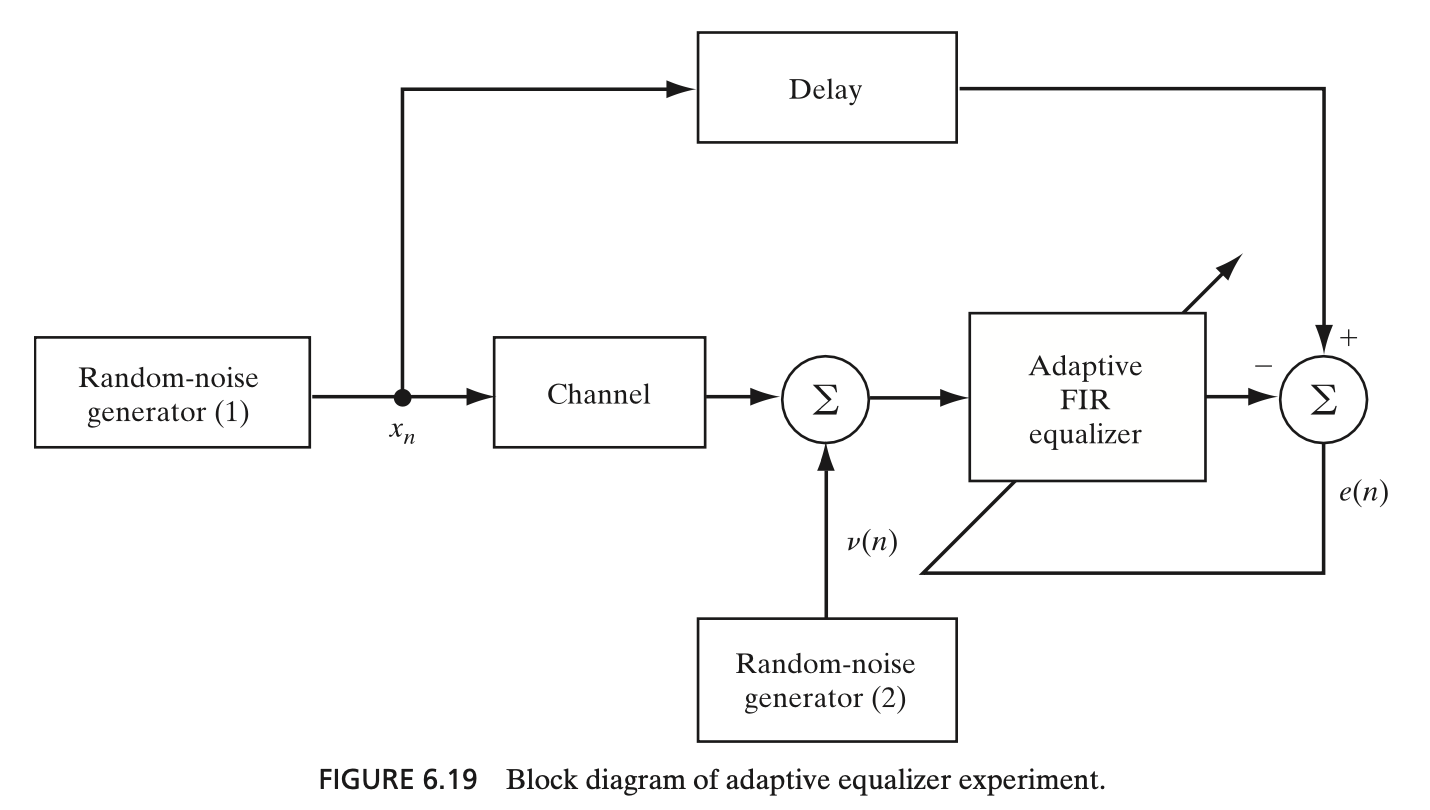
#### 6.8 Computer Experiment on Adaptive Equalization

### . Adaptive Predictor (Order $M=1$)
* **Prediction:** $\hat{u}(n) = \hat{w}(n) u(n-1)$
* **Error:** $e(n) = u(n) - \hat{w}(n) u(n-1)$
* **LMS Update:** $\hat{w}(n+1) = \hat{w}(n) + \mu u(n-1) e(n)$
* **Weight Error:** $\tilde{w}(n) = w_o - \hat{w}(n)$, where $w_o = -a$

---

### 📌 System Model (Section 6.8: Adaptive Equalization)

#### 1. Goal of the Experiment
Study the behavior of the LMS algorithm in a vector environment where performance is dictated by the **eigenvalue spread** of the channel.

#### 2. Signal and Channel
* **Transmitted Signal:** $d(n) \in \{-1, +1\}$, i.i.d. sequence with variance $\sigma_d^2 = 1$.
* **Channel:** FIR filter $h$ representing Inter-symbol Interference (ISI). Received signal $x(n) = \mathbf{h}^T \mathbf{d}(n)$.
* **Additive Noise:** $r(n) = x(n) + v(n)$, where $v(n) \sim \mathcal{N}(0, \sigma_v^2)$.

#### 3. Equalizer Structure
* **Output:** $y(n) = \mathbf{w}^T(n) \mathbf{r}(n)$
* **Error:** $e(n) = d(n - \Delta) - y(n)$, where $\Delta$ is the decision delay.
* **Vector LMS Update:** $\mathbf{w}(n+1) = \mathbf{w}(n) + \mu \mathbf{r}(n) e(n)$

---

### 📌 Theory to Validate

| Metric | Theoretical Formula |
| :--- | :--- |
| **Mean Convergence** | $E[\tilde{\mathbf{w}}(n)] = (\mathbf{I} - \mu \mathbf{R})^n \tilde{\mathbf{w}}(0)$ |
| **Mean-Square Error** | $J(n) = J_{min} + J_{ex}(n)$ |
| **Steady-State Excess MSE** | $J_{ex}(\infty) = \frac{J_{min} \sum_{i=1}^M \frac{\mu \lambda_i}{2 - \mu \lambda_i}}{1 - \sum_{i=1}^M \frac{\mu \lambda_i}{2 - \mu \lambda_i}}$ |
| **Misadjustment ($M$)** | $M \approx \frac{\mu}{2} \text{tr}(\mathbf{R})$ (for small $\mu$) |
| **Stability Condition** | $0 < \mu < \frac{2}{\lambda_{max}}$ |

---

### 📌 Key Differences & Observations

### 1. Scalar vs. Vector LMS
Unlike the AR(1) case (single eigenvalue), equalization involves a correlation matrix $\mathbf{R}$ with an **eigenvalue spread** $\kappa = \lambda_{max} / \lambda_{min}$.
* **Large $\kappa$:** Leads to slow convergence as the error surface is highly elliptical (steep in some directions, flat in others).

### 2. Effect of Step-Size $\mu$
* **Larger $\mu$:** Faster initial convergence but significantly higher steady-state "rattle" and risk of instability if $\mu \lambda_{max} > 2$.
* **Smaller $\mu$:** Robust stability and lower Misadjustment, but convergence is dictated by the slowest mode ($1 - \mu \lambda_{min}$).

### 3. Why This Matters
This experiment demonstrates that LMS performance is not just a function of noise, but of the **input statistics**. Highly distorted channels (large ISI) increase the eigenvalue spread, making equalization significantly harder than simple prediction.

---

### 📌 Experimental Setup
* **Parameters:** $N_{ensemble} = 100$, $N_{samples} = 500$–$1000$.
* **Equalizer Taps:** $M=11$ (typical for Haykin experiments).
* **Measurements:**
   1. Learning Curves: Compare for varying channel eigenvalue spreads (varying ISI).
   2. Eigenvalue Analysis: Calculate $\mathbf{R}$ and find $\kappa$ to predict convergence time.

Running W = 2.9
Running W = 3.1
Running W = 3.3
Running W = 3.5


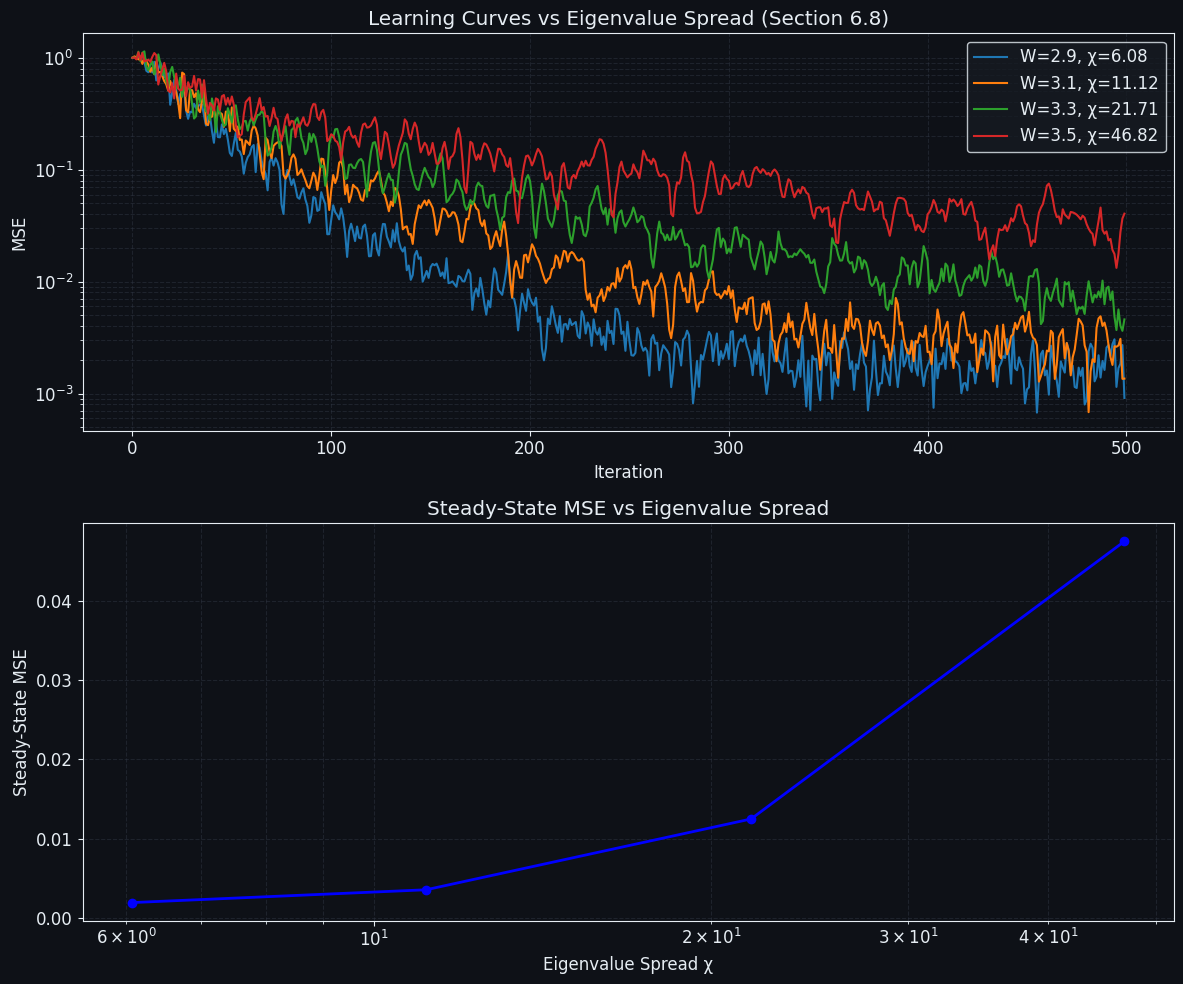

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# PARAMETERS (Haykin Section 6.8)
# =============================================================

N_sample    = 500
N_ensemble  = 200
N_ch_taps   = 3
N_eq_taps   = 11
N_init      = 50

mu          = 0.03        # stable for all W
noise_var   = 0.001
noise_std   = np.sqrt(noise_var)

Ws = [2.9, 3.1, 3.3, 3.5]

rng = np.random.default_rng(123)


# =============================================================
# CHANNEL IMPULSE RESPONSE
# =============================================================

def chnlResp(W, N_taps=3):
    h = np.zeros(N_taps)
    for n in range(1, N_taps + 1):
        h[n-1] = 0.5 * (1 + np.cos((2*np.pi/W)*(n - 2)))
    return h


# =============================================================
# CORRELATION MATRIX (Toeplitz Approximation)
# =============================================================

def corrMatrix(h, noise_var, M):
    h0, h1, h2 = h
    r0 = h0*h0 + h1*h1 + h2*h2 + noise_var
    r1 = h0*h1 + h1*h2
    r2 = h0*h2

    R = np.zeros((M, M))
    for i in range(M):
        R[i,i] = r0
        if i+1 < M:
            R[i,i+1] = r1
            R[i+1,i] = r1
        if i+2 < M:
            R[i,i+2] = r2
            R[i+2,i] = r2

    return 0.5*(R + R.T)


def eigenSpread(h):
    R = corrMatrix(h, noise_var, N_eq_taps)
    eigvals = np.linalg.eigvalsh(R)
    return eigvals[-1] / eigvals[0]


# =============================================================
# SIMPLE REAL LMS CLASS (no 2μ)
# =============================================================

class LMS:
    def __init__(self, mu, M):
        self.mu = mu
        self.M = M
        self.w = np.zeros(M)

    def run(self, x, d):
        N = len(x)
        e_hist = np.zeros(N)

        x_pad = np.concatenate([np.zeros(self.M-1), x])

        for n in range(N):
            reg = x_pad[n:n+self.M][::-1]
            y = np.dot(self.w, reg)
            e = d[n] - y
            self.w += self.mu * e * reg
            e_hist[n] = e

        return e_hist


# =============================================================
# MAIN EXPERIMENT
# =============================================================

err_hist = {W: np.zeros(N_sample) for W in Ws}

for W in Ws:
    print(f"Running W = {W}")

    h = chnlResp(W)
    D = N_ch_taps//2 + N_eq_taps//2

    mse_runs = np.zeros((N_ensemble, N_sample))

    for m in range(N_ensemble):

        total_len = N_sample + D + N_eq_taps + N_init

        d = rng.choice([-1, +1], total_len)
        v = rng.normal(0, noise_std, total_len)

        u = np.convolve(d, h)[:total_len] + v

        # Align signals
        u_cut = u[D:D+N_sample]
        d_cut = d[:N_sample]

        lms = adspfilter.LMS(mu=mu/2, filter_order=N_eq_taps - 1)
        
        y_hist, e_hist, w_hist = lms(u_cut, d_cut, train=True)
        
        mse_runs[m] = e_hist.real ** 2

    err_hist[W] = np.mean(mse_runs, axis=0)


# =============================================================
# PLOT RESULTS
# =============================================================

plt.figure(figsize=(12,10))

# Learning curves
plt.subplot(2,1,1)

for W in Ws:
    chi = eigenSpread(chnlResp(W))
    plt.semilogy(err_hist[W], label=f"W={W}, χ={chi:.2f}")

plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Learning Curves vs Eigenvalue Spread (Section 6.8)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

# Steady-state vs spread
plt.subplot(2,1,2)

spreads = []
ss_mse = []

for W in Ws:
    chi = eigenSpread(chnlResp(W))
    spreads.append(chi)
    ss_mse.append(np.mean(err_hist[W][300:]))

plt.plot(spreads, ss_mse, 'bo-', linewidth=2)
plt.xscale("log")
plt.xlabel("Eigenvalue Spread χ")
plt.ylabel("Steady-State MSE")
plt.title("Steady-State MSE vs Eigenvalue Spread")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
